# 03 — Model Experiments

Target: label (0 = normal, 1 = attack).

Initial model inputs exclude id, attack_cat, label, and is_ftp_login.
The FTP field is excluded because it duplicates ct_ftp_cmd in the
official training data and has an unresolved binary-value discrepancy.

Use the saved internal split. Fit preprocessing and models on the
training partition, and evaluate choices on validation.

The official test set remains reserved for final evaluation.

In [1]:
from pathlib import Path

import pandas as pd

project_root = Path.cwd().parent

# Load the original development data and saved split assignments.
official_train_df = pd.read_csv(project_root / "data" / "raw" / "UNSW_NB15_training-set.csv")
split_assignments = pd.read_csv(project_root / "data" / "processed" / "train_validation_split.csv")

# Get the record IDs assigned to each partition.
fit_ids = split_assignments.loc[
    split_assignments["partition"].eq("training"), "id"
]
validation_ids = split_assignments.loc[
    split_assignments["partition"].eq("validation"), "id"
]

# Recover the corresponding records.
fit_df = official_train_df.loc[
    official_train_df["id"].isin(fit_ids)
].copy()

validation_df = official_train_df.loc[
    official_train_df["id"].isin(validation_ids)
].copy()

# Check that all assigned records were recovered without overlapping IDs.
assert len(fit_df) == len(fit_ids)
assert len(validation_df) == len(validation_ids)
assert set(fit_ids).isdisjoint(validation_ids)
assert len(fit_df) + len(validation_df) == len(official_train_df)

In [2]:
# Confirm the duplicate-feature finding in the training partition.
assert fit_df["is_ftp_login"].eq(fit_df["ct_ftp_cmd"]).all()

excluded_columns = ["id", "attack_cat", "label", "is_ftp_login"]

# X contains the traffic measurements supplied to the model.
X_fit = fit_df.drop(columns=excluded_columns)
X_validation = validation_df.drop(columns=excluded_columns)

# y contains the corresponding correct answers.
y_fit = fit_df["label"].copy()
y_validation = validation_df["label"].copy()

print("X_fit:", X_fit.shape)
print("y_fit:", y_fit.shape)
print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

X_fit: (140272, 41)
y_fit: (140272,)
X_validation: (35069, 41)
y_validation: (35069,)


In [3]:
# These text columns need categorical encoding.
categorical_columns = ["proto", "service", "state"]

# Select the numerical measurements by their stored data types.
numerical_columns = X_fit.select_dtypes(
    include="number"
).columns.tolist()

# Ensure that every input column has been accounted for.
assert set(categorical_columns + numerical_columns) == set(X_fit.columns)

print("Categorical columns:", categorical_columns)
print("Numerical column count:", len(numerical_columns))

Categorical columns: ['proto', 'service', 'state']
Numerical column count: 38


In [4]:
X_fit.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,...,1,1,1,1,2,0,0,1,6,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,...,1,2,1,1,3,0,0,2,6,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,...,1,2,1,1,3,1,0,2,1,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,...,1,2,2,1,40,0,0,2,39,0
5,0.380537,tcp,-,FIN,10,6,534,268,39.417980,254,...,1,2,2,1,40,0,0,2,39,0


In [5]:
y_fit.head()

1    0
2    0
3    0
4    0
5    0
Name: label, dtype: int64

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Apply a different transformation to each type of input.
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numerical_columns),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns,
        ),
    ]
)

In [7]:
# Learn means, standard deviations, and categories from training only.
# Then transform the training inputs using those learned settings.
X_fit_prepared = preprocessor.fit_transform(X_fit)

# Apply the SAME settings to validation without learning them again.
X_validation_prepared = preprocessor.transform(X_validation)

print("Prepared training shape:", X_fit_prepared.shape)
print("Prepared validation shape:", X_validation_prepared.shape)

Prepared training shape: (140272, 192)
Prepared validation shape: (35069, 192)


In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Learn the most common training label.
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_fit_prepared, y_fit)

# Predict validation labels without using their correct answers.
dummy_predictions = dummy_model.predict(X_validation_prepared)

# Compare predictions against the actual validation labels.
dummy_accuracy = accuracy_score(y_validation, dummy_predictions)
print(f"Dummy validation accuracy: {dummy_accuracy:.2%}")

# Rows show actual labels; columns show predicted labels.
dummy_confusion = pd.DataFrame(
    confusion_matrix(y_validation, dummy_predictions, labels=[0, 1]),
    index=["Actual normal", "Actual attack"],
    columns=["Predicted normal", "Predicted attack"],
)

display(dummy_confusion)

Dummy validation accuracy: 68.06%


,Predicted normal,Predicted attack
Actual normal,0,11200
Actual attack,0,23869


In [9]:
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Keep preprocessing and classification together.
logistic_model = Pipeline(
    steps=[
        ("preprocessing", clone(preprocessor)),
        ("classifier", LogisticRegression(max_iter=1000)),
    ]
)

# Learn preprocessing settings and model weights from training only.
logistic_model.fit(X_fit, y_fit)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](41,)","['dur','proto','service',...,'ct_src_ltm','ct_srv_dst','is_sm_ips_ports']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,41
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='

In [10]:
# The pipeline transforms validation inputs and predicts their labels.
logistic_predictions = logistic_model.predict(X_validation)

# Compare accuracy with the majority-class baseline.
logistic_accuracy = accuracy_score(y_validation, logistic_predictions)

print(f"Dummy validation accuracy:    {dummy_accuracy:.2%}")
print(f"Logistic validation accuracy: {logistic_accuracy:.2%}")

# Inspect both false alarms and missed attacks.
logistic_confusion = pd.DataFrame(
    confusion_matrix(y_validation, logistic_predictions, labels=[0, 1]),
    index=["Actual normal", "Actual attack"],
    columns=["Predicted normal", "Predicted attack"],
)

display(logistic_confusion)

Dummy validation accuracy:    68.06%
Logistic validation accuracy: 93.68%


,Predicted normal,Predicted attack
Actual normal,9271,1929
Actual attack,286,23583


In [11]:
def summarize_predictions(y_true, y_pred):
    # With labels [0, 1], the four cells are TN, FP, FN, TP.
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    return {
        "accuracy": (tp + tn) / (tn + fp + fn + tp),
        "precision": tp / (tp + fp) if tp + fp else 0.0,
        "recall": tp / (tp + fn) if tp + fn else 0.0,
        "false_positive_rate": fp / (tn + fp) if tn + fp else 0.0,
    }


# Compare both models on the same validation records.
validation_results = pd.DataFrame(
    {
        "Dummy": summarize_predictions(y_validation, dummy_predictions),
        "Logistic regression": summarize_predictions(
            y_validation, logistic_predictions
        ),
    }
).T

display((validation_results * 100).round(2))

,accuracy,precision,recall,false_positive_rate
Dummy,68.06,68.06,100.0,100.00
Logistic regression,93.68,92.44,98.8,17.22


In [12]:
# Use the original proportions stored in validation_results.
precision = validation_results["precision"]
recall = validation_results["recall"]

# Combine precision and recall into the F1 score.
validation_results["f1"] = (
    2 * precision * recall / (precision + recall)
)

# Display percentages without changing the stored proportions.
display((validation_results * 100).round(2))

,accuracy,precision,recall,false_positive_rate,f1
Dummy,68.06,68.06,100.0,100.00,81.00
Logistic regression,93.68,92.44,98.8,17.22,95.51


### Initial baseline findings

- The majority-class dummy model predicts every record as an attack.
  It achieves 68.06% accuracy and 100% attack recall, but incorrectly
  flags every normal record.

- Logistic regression achieves 93.68% validation accuracy,
  92.44% attack precision, 98.80% attack recall, and 95.51% attack F1.

- Its false-positive rate is 17.22%: 1,929 of 11,200 normal records
  are incorrectly flagged. It also misses 286 of 23,869 attacks.

- Accuracy and recall alone are insufficient to assess this detector.
  False alarms and missed attacks must both be considered.

- These are internal validation results. The official test set has
  not been used for model evaluation.

In [13]:
# Find the probability column corresponding to attack (label 1).
attack_column = list(logistic_model.classes_).index(1)

# Get an estimated attack probability for every validation record.
validation_attack_probabilities = logistic_model.predict_proba(
    X_validation
)[:, attack_column]

# Compare a few estimated probabilities with the actual labels.
probability_preview = pd.DataFrame(
    {
        "actual_label": y_validation,
        "attack_probability": validation_attack_probabilities,
        "default_prediction": logistic_predictions,
    }
)

display(probability_preview.head(10))

,actual_label,attack_probability,default_prediction
0,0,0.687317,1
8,0,0.006777,0
11,0,0.995450,1
15,0,0.995630,1
18,0,0.006300,0
19,0,0.005763,0
32,0,0.883827,1
33,0,0.809394,1
36,0,0.856999,1
37,0,0.635233,1


In [14]:
threshold_rows = []

for threshold in [0.3, 0.5, 0.7]:
    # Convert probabilities into labels using this cutoff.
    predictions_at_threshold = (
        validation_attack_probabilities > threshold
    ).astype(int)

    # Reuse our evaluation function.
    metrics = summarize_predictions(
        y_validation, predictions_at_threshold
    )
    metrics["threshold"] = threshold
    threshold_rows.append(metrics)

# Keep thresholds as the index and display metrics as percentages.
threshold_results = pd.DataFrame(threshold_rows).set_index("threshold")
display((threshold_results * 100).round(2))

,accuracy,precision,recall,false_positive_rate
threshold,,,,
0.3,93.54,91.72,99.49,19.14
0.5,93.68,92.44,98.80,17.22
0.7,93.23,95.60,94.40,9.27


Validation ROC AUC: 0.9844


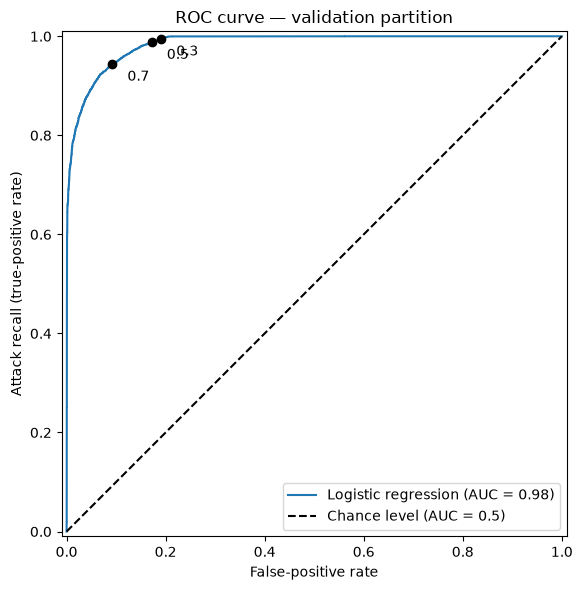

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, roc_auc_score

# Evaluate the probability scores across thresholds.
logistic_roc_auc = roc_auc_score(
    y_validation, validation_attack_probabilities
)
print(f"Validation ROC AUC: {logistic_roc_auc:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))

# Use probability scores to draw the ROC curve.
RocCurveDisplay.from_predictions(
    y_validation,
    validation_attack_probabilities,
    name="Logistic regression",
    plot_chance_level=True,
    ax=ax,
)

# Mark the three thresholds we already examined.
for threshold, row in threshold_results.iterrows():
    fpr = row["false_positive_rate"]
    recall = row["recall"]

    ax.scatter(fpr, recall, color="black", zorder=3)
    ax.annotate(
        f"  {threshold:.1f}",
        (fpr, recall),
        xytext=(5, -12),
        textcoords="offset points",
    )

ax.set_title("ROC curve — validation partition")
ax.set_xlabel("False-positive rate")
ax.set_ylabel("Attack recall (true-positive rate)")
plt.tight_layout()
plt.show()

Validation average precision: 0.9917


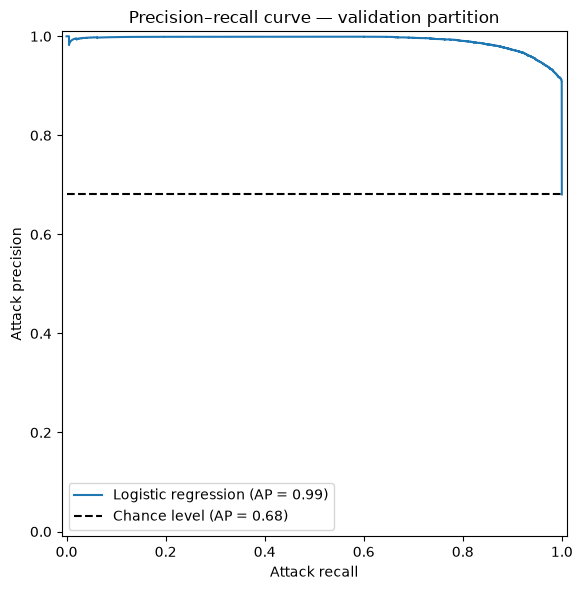

In [16]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

# Summarize precision across recall levels using probability scores.
logistic_ap = average_precision_score(
    y_validation, validation_attack_probabilities
)
print(f"Validation average precision: {logistic_ap:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))

# Show how precision and recall change across thresholds.
PrecisionRecallDisplay.from_predictions(
    y_validation,
    validation_attack_probabilities,
    name="Logistic regression",
    plot_chance_level=True,
    ax=ax,
)

ax.set_title("Precision–recall curve — validation partition")
ax.set_xlabel("Attack recall")
ax.set_ylabel("Attack precision")
plt.tight_layout()
plt.show()

In [17]:
# Evaluate the fitted model on the records it learned from.
# predict() does not retrain the model.
logistic_training_predictions = logistic_model.predict(X_fit)

# Compare training and validation at the same default threshold.
logistic_partition_results = pd.DataFrame(
    {
        "Training": summarize_predictions(
            y_fit, logistic_training_predictions
        ),
        "Validation": summarize_predictions(
            y_validation, logistic_predictions
        ),
    }
).T

# Display all metrics as percentages.
display((logistic_partition_results * 100).round(2))

,accuracy,precision,recall,false_positive_rate
Training,93.51,92.23,98.79,17.74
Validation,93.68,92.44,98.80,17.22


### Baseline evaluation summary

- Logistic regression has similar training and validation performance:
  accuracy is 93.51% on training and 93.68% on validation.
  This comparison shows no large generalization gap on this split.

- Validation ROC AUC is 0.9844 and average precision is 0.9917.
  These summarize ranking performance across thresholds.

- At the default threshold of 0.5, attack recall is 98.80%,
  but the false-positive rate is 17.22%.

- Raising the threshold to 0.7 reduces the false-positive rate to
  9.27%, while attack recall falls to 94.40%.

- We retain 0.5 as the reference threshold for initial model comparisons.
  A final operating threshold has not been selected.

- The official test set remains unused for model evaluation.